# Modelo de Clasificación — Predicción de Puntaje Global Saber 11

**Proyecto 2 — Analítica Computacional para la Toma de Decisiones**  
**Universidad de los Andes**  
**Autor:** Luis Enrique Restrepo
**Rol:** Ciencia de Datos  

**Pregunta de negocio:** ¿Es posible predecir si un estudiante proviene de una zona rural o urbana a partir únicamente de sus resultados y perfil familiar, y qué tan marcada es esa brecha en Bolívar?

## 1. Carga de datos limpios

Cargamos el dataframe ya procesado por el script de limpieza `Proyecto2.py`

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Configuración de visualización
pd.set_option('display.max_columns', None)
sns.set_style('whitegrid')

In [3]:
df = pd.read_csv('DatosSaber11_Bolivar_limpio_todas_columnas.csv')
print(f"Filas: {df.shape[0]:,}")
print(f"Columnas: {df.shape[1]}")
df.head()
df.dtypes

Filas: 122,866
Columnas: 52


estu_consecutivo                  object
periodo                            int64
estu_fechanacimiento              object
edad                               int64
estu_genero                       object
cole_area_ubicacion               object
cole_mcpio_ubicacion              object
cole_calendario                   object
cole_bilingue                     object
cole_naturaleza                   object
cole_genero                       object
cole_caracter                     object
fami_estratovivienda              object
fami_tienecomputador              object
fami_tieneinternet                object
fami_educacionmadre               object
fami_educacionpadre               object
punt_ingles                      float64
punt_matematicas                 float64
punt_lectura_critica               int64
punt_c_naturales                   int64
punt_sociales_ciudadanas           int64
punt_global                      float64
estu_tipodocumento                object
cole_cod_dane_es

In [4]:
num_cols = df.select_dtypes(include='number').columns.tolist()
cat_cols = df.select_dtypes(include='object').columns.tolist()

print(f"Numéricas ({len(num_cols)}):    {num_cols}")
print(f"\nCategóricas ({len(cat_cols)}): {cat_cols}")

Numéricas (17):    ['periodo', 'edad', 'punt_ingles', 'punt_matematicas', 'punt_lectura_critica', 'punt_c_naturales', 'punt_sociales_ciudadanas', 'punt_global', 'cole_cod_dane_establecimiento', 'cole_cod_dane_sede', 'cole_cod_depto_ubicacion', 'cole_cod_mcpio_ubicacion', 'cole_codigo_icfes', 'estu_cod_depto_presentacion', 'estu_cod_mcpio_presentacion', 'estu_cod_reside_depto', 'estu_cod_reside_mcpio']

Categóricas (35): ['estu_consecutivo', 'estu_fechanacimiento', 'estu_genero', 'cole_area_ubicacion', 'cole_mcpio_ubicacion', 'cole_calendario', 'cole_bilingue', 'cole_naturaleza', 'cole_genero', 'cole_caracter', 'fami_estratovivienda', 'fami_tienecomputador', 'fami_tieneinternet', 'fami_educacionmadre', 'fami_educacionpadre', 'estu_tipodocumento', 'cole_depto_ubicacion', 'cole_jornada', 'cole_nombre_establecimiento', 'cole_nombre_sede', 'cole_sede_principal', 'estu_depto_presentacion', 'estu_depto_reside', 'estu_estadoinvestigacion', 'estu_estudiante', 'estu_mcpio_presentacion', 'estu_mc

Variable Ojetivo

In [5]:
TARGET = 'cole_area_ubicacion'

print("Valores únicos:", df[TARGET].unique())
print("\nConteo:")
print(df[TARGET].value_counts())
print("\nProporción %:")
print((df[TARGET].value_counts(normalize=True) * 100).round(2))

Valores únicos: ['URBANO' 'RURAL']

Conteo:
cole_area_ubicacion
URBANO    100877
RURAL      21989
Name: count, dtype: int64

Proporción %:
cole_area_ubicacion
URBANO    82.1
RURAL     17.9
Name: proportion, dtype: float64


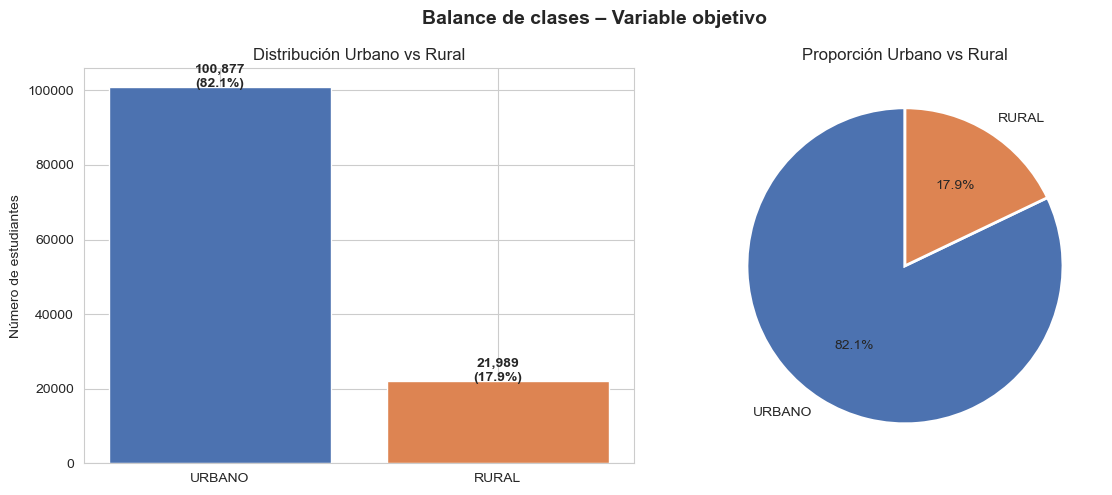


Ratio desbalance: 4.59x


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
counts = df[TARGET].value_counts()

axes[0].bar(counts.index, counts.values, color=['#4C72B0', '#DD8452'], edgecolor='white')
for i, (val, count) in enumerate(zip(counts.index, counts.values)):
    axes[0].text(i, count + 50, f'{count:,}\n({count/len(df)*100:.1f}%)',
                 ha='center', fontweight='bold')
axes[0].set_title('Distribución Urbano vs Rural')
axes[0].set_ylabel('Número de estudiantes')

axes[1].pie(counts.values, labels=counts.index, autopct='%1.1f%%',
            colors=['#4C72B0', '#DD8452'], startangle=90,
            wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[1].set_title('Proporción Urbano vs Rural')

plt.suptitle('Balance de clases – Variable objetivo', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"\nRatio desbalance: {counts.iloc[0]/counts.iloc[1]:.2f}x")

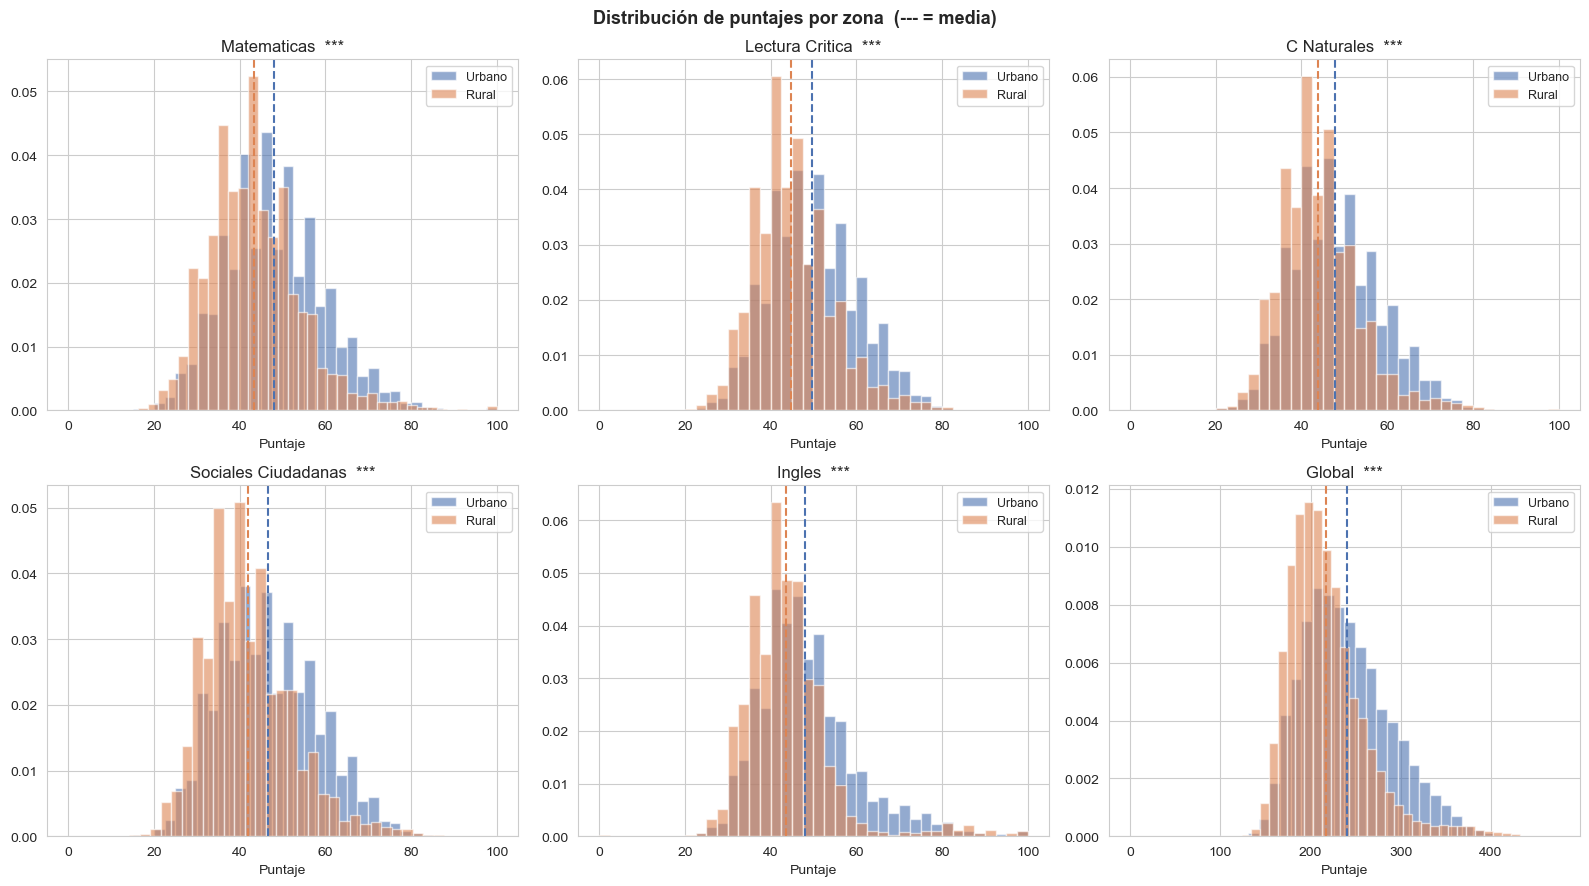

In [7]:
puntajes = ['punt_matematicas', 'punt_lectura_critica', 'punt_c_naturales',
            'punt_sociales_ciudadanas', 'punt_ingles', 'punt_global']

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

for i, col in enumerate(puntajes):
    urbano = df[df[TARGET] == 'URBANO'][col].dropna()
    rural  = df[df[TARGET] == 'RURAL'][col].dropna()

    axes[i].hist(urbano, bins=40, alpha=0.6, label='Urbano', color='#4C72B0', density=True)
    axes[i].hist(rural,  bins=40, alpha=0.6, label='Rural',  color='#DD8452', density=True)
    axes[i].axvline(urbano.mean(), color='#4C72B0', linestyle='--', linewidth=1.5)
    axes[i].axvline(rural.mean(),  color='#DD8452', linestyle='--', linewidth=1.5)

    t_stat, p_val = stats.ttest_ind(urbano, rural)
    sig = '***' if p_val < 0.001 else ('**' if p_val < 0.01 else ('*' if p_val < 0.05 else 'ns'))

    nombre = col.replace('punt_','').replace('_',' ').title()
    axes[i].set_title(f"{nombre}  {sig}")
    axes[i].set_xlabel('Puntaje')
    axes[i].legend(fontsize=9)

plt.suptitle('Distribución de puntajes por zona  (--- = media)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

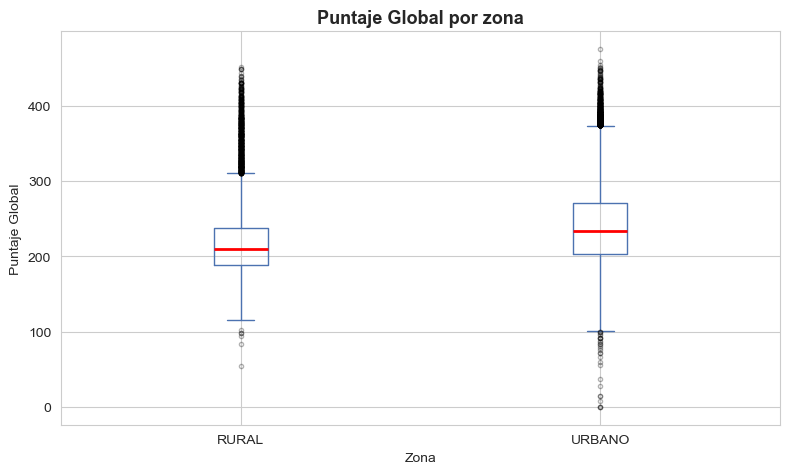

In [8]:
fig, ax = plt.subplots(figsize=(8, 5))
df.boxplot(column='punt_global', by=TARGET, ax=ax,
           boxprops=dict(color='#4C72B0'),
           medianprops=dict(color='red', linewidth=2),
           whiskerprops=dict(color='#4C72B0'),
           capprops=dict(color='#4C72B0'),
           flierprops=dict(marker='o', alpha=0.3, markersize=3))
ax.set_title('Puntaje Global por zona', fontsize=13, fontweight='bold')
ax.set_xlabel('Zona')
ax.set_ylabel('Puntaje Global')
plt.suptitle('')
plt.tight_layout()
plt.show()

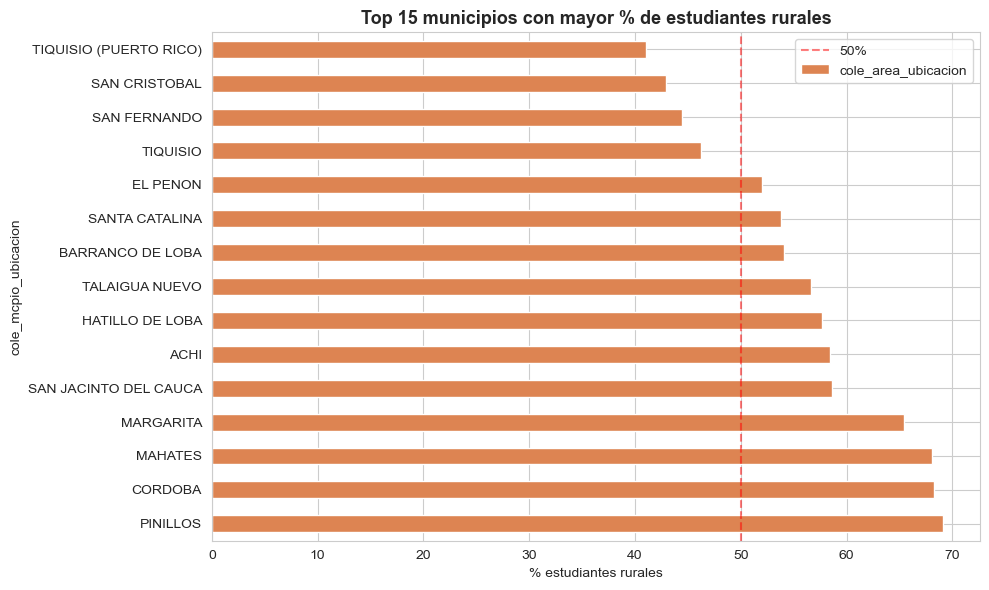

In [9]:
municipios = (df.groupby('cole_mcpio_ubicacion')[TARGET]
                .apply(lambda x: (x == 'RURAL').mean() * 100)
                .sort_values(ascending=False)
                .head(15))

fig, ax = plt.subplots(figsize=(10, 6))
municipios.plot(kind='barh', ax=ax, color='#DD8452', edgecolor='white')
ax.set_title('Top 15 municipios con mayor % de estudiantes rurales', fontsize=13, fontweight='bold')
ax.set_xlabel('% estudiantes rurales')
ax.axvline(50, color='red', linestyle='--', alpha=0.5, label='50%')
ax.legend()
plt.tight_layout()
plt.show()

In [10]:
cat_int_feats = []   # en este dataset estrato y género son string

cat_str_feats = ['estu_genero', 'fami_estratovivienda',
                 'fami_educacionpadre', 'fami_educacionmadre',
                 'fami_tieneinternet', 'fami_tienecomputador',
                 'fami_tieneautomovil', 'fami_tienelavadora',
                 'cole_naturaleza', 'cole_jornada', 'cole_bilingue',
                 'cole_caracter', 'cole_calendario']

num_feats = ['punt_matematicas', 'punt_lectura_critica', 'punt_c_naturales',
             'punt_sociales_ciudadanas', 'punt_ingles', 'punt_global',
             'edad']

# Verificar existencia
cat_str_feats = [c for c in cat_str_feats if c in df.columns]
num_feats     = [c for c in num_feats     if c in df.columns]

print("Categóricas string:", cat_str_feats)
print("Numéricas:         ", num_feats)

all_feats = cat_int_feats + cat_str_feats + num_feats
df_model  = df[all_feats + [TARGET]].dropna().copy()
df_model[TARGET] = (df_model[TARGET] == 'URBANO').astype(int)

print(f"\nFilas para modelar: {len(df_model):,}")
print(f"Balance:\n{df_model[TARGET].value_counts()}")
df_model.head()

Categóricas string: ['estu_genero', 'fami_estratovivienda', 'fami_educacionpadre', 'fami_educacionmadre', 'fami_tieneinternet', 'fami_tienecomputador', 'fami_tieneautomovil', 'fami_tienelavadora', 'cole_naturaleza', 'cole_jornada', 'cole_bilingue', 'cole_caracter', 'cole_calendario']
Numéricas:          ['punt_matematicas', 'punt_lectura_critica', 'punt_c_naturales', 'punt_sociales_ciudadanas', 'punt_ingles', 'punt_global', 'edad']

Filas para modelar: 122,866
Balance:
cole_area_ubicacion
1    100877
0     21989
Name: count, dtype: int64


,estu_genero,fami_estratovivienda,fami_educacionpadre,fami_educacionmadre,fami_tieneinternet,fami_tienecomputador,fami_tieneautomovil,fami_tienelavadora,cole_naturaleza,cole_jornada,cole_bilingue,cole_caracter,cole_calendario,punt_matematicas,punt_lectura_critica,punt_c_naturales,punt_sociales_ciudadanas,punt_ingles,punt_global,edad,cole_area_ubicacion
0,M,ESTRATO 1,PRIMARIA COMPLETA,SECUNDARIA (BACHILLERATO) COMPLETA,NO,NO,No,Si,OFICIAL,MAÑANA,N,ACADEMICO,A,47.0,49,51,32,51.0,226.0,17,1
1,M,ESTRATO 3,EDUCACION PROFESIONAL COMPLETA,EDUCACION PROFESIONAL COMPLETA,SI,SI,No,Si,OFICIAL,TARDE,N,TECNICO/ACADEMICO,A,62.0,68,67,71,100.0,348.0,17,1
2,F,ESTRATO 3,NINGUNO,SECUNDARIA (BACHILLERATO) COMPLETA,NO,NO,No,Si,OFICIAL,MAÑANA,N,ACADEMICO,A,26.0,36,39,25,39.0,160.0,16,1
3,M,SIN ESTRATO,SECUNDARIA (BACHILLERATO) COMPLETA,SECUNDARIA (BACHILLERATO) COMPLETA,SI,NO,No,Si,OFICIAL,MAÑANA,N,ACADEMICO,A,25.0,35,36,32,42.0,164.0,17,0
4,F,ESTRATO 1,TECNICA O TECNOLOGICA INCOMPLETA,TECNICA O TECNOLOGICA INCOMPLETA,SI,SI,No,Si,OFICIAL,NOCHE,N,ACADEMICO,A,52.0,52,51,48,45.0,252.0,18,1


In [11]:
cat_str_feats = ['estu_genero', 'fami_estratovivienda',
                 'fami_educacionpadre', 'fami_educacionmadre',
                 'fami_tieneinternet', 'fami_tienecomputador',
                 'fami_tieneautomovil', 'fami_tienelavadora',
                 'cole_naturaleza', 'cole_jornada', 'cole_bilingue',
                 'cole_caracter', 'cole_calendario']

num_feats = ['punt_matematicas', 'punt_lectura_critica', 'punt_c_naturales',
             'punt_sociales_ciudadanas', 'punt_ingles', 'punt_global', 'edad']

cat_str_feats = [c for c in cat_str_feats if c in df.columns]
num_feats     = [c for c in num_feats     if c in df.columns]

print("Categóricas string:", cat_str_feats)
print("Numéricas:         ", num_feats)

all_feats = cat_str_feats + num_feats
df_model  = df[all_feats + [TARGET]].dropna().copy()
df_model[TARGET] = (df_model[TARGET] == 'URBANO').astype(int)

print(f"\nFilas para modelar: {len(df_model):,}")
print(f"\nBalance:")
print(df_model[TARGET].value_counts())
print(df_model[TARGET].value_counts(normalize=True).round(3) * 100)

Categóricas string: ['estu_genero', 'fami_estratovivienda', 'fami_educacionpadre', 'fami_educacionmadre', 'fami_tieneinternet', 'fami_tienecomputador', 'fami_tieneautomovil', 'fami_tienelavadora', 'cole_naturaleza', 'cole_jornada', 'cole_bilingue', 'cole_caracter', 'cole_calendario']
Numéricas:          ['punt_matematicas', 'punt_lectura_critica', 'punt_c_naturales', 'punt_sociales_ciudadanas', 'punt_ingles', 'punt_global', 'edad']

Filas para modelar: 122,866

Balance:
cole_area_ubicacion
1    100877
0     21989
Name: count, dtype: int64
cole_area_ubicacion
1    82.1
0    17.9
Name: proportion, dtype: float64


In [13]:
import tensorflow as tf
import keras
import os
os.environ["KERAS_BACKEND"] = "tensorflow"

print("TensorFlow:", tf.__version__)
print("Keras:", keras.__version__)

TensorFlow: 2.21.0
Keras: 3.14.1


Seprar entre train y test

In [14]:
train = df_model.sample(frac=0.8, random_state=42)
test  = df_model.drop(train.index)

val   = train.sample(frac=0.2, random_state=42)
train = train.drop(val.index)

print(f"Train: {train.shape[0]:,} filas")
print(f"Val:   {val.shape[0]:,} filas")
print(f"Test:  {test.shape[0]:,} filas")

Train: 78,634 filas
Val:   19,659 filas
Test:  24,573 filas


Convertir a tf.Dataset

In [15]:
def dataframe_to_dataset(dataframe):
    dataframe = dataframe.copy()
    labels = dataframe.pop(TARGET)
    ds = tf.data.Dataset.from_tensor_slices((dict(dataframe), labels))
    ds = ds.shuffle(buffer_size=len(dataframe))
    return ds

train_ds = dataframe_to_dataset(train)
val_ds   = dataframe_to_dataset(val)
test_ds  = dataframe_to_dataset(test)

batch_size = 32
train_ds = train_ds.batch(batch_size)
val_ds   = val_ds.batch(batch_size)
test_ds  = test_ds.batch(batch_size)

print("Datasets creados")
for x, y in train_ds.take(1):
    print("Features:", list(x.keys()))
    print("Etiquetas ejemplo:", y.numpy()[:5])

Datasets creados
Features: ['estu_genero', 'fami_estratovivienda', 'fami_educacionpadre', 'fami_educacionmadre', 'fami_tieneinternet', 'fami_tienecomputador', 'fami_tieneautomovil', 'fami_tienelavadora', 'cole_naturaleza', 'cole_jornada', 'cole_bilingue', 'cole_caracter', 'cole_calendario', 'punt_matematicas', 'punt_lectura_critica', 'punt_c_naturales', 'punt_sociales_ciudadanas', 'punt_ingles', 'punt_global', 'edad']
Etiquetas ejemplo: [1 0 1 1 1]


Funciones de codificación para ayuda a normalizar variables como el puntaje y la edad, tmabien las que son varuables como SI/NO a numeros para la redes

In [16]:
def encode_numerical_feature(feature, name, dataset):
    normalizer = keras.layers.Normalization()
    feature_ds = dataset.map(lambda x, y: x[name])
    feature_ds = feature_ds.map(lambda x: tf.expand_dims(x, -1))
    normalizer.adapt(feature_ds)
    return normalizer(feature)

def encode_categorical_feature(feature, name, dataset, is_string):
    lookup = keras.layers.StringLookup(output_mode="binary")
    feature_ds = dataset.map(lambda x, y: x[name])
    feature_ds = feature_ds.map(lambda x: tf.expand_dims(x, -1))
    lookup.adapt(feature_ds)
    return lookup(feature)


In [17]:
inputs = []

for feat in cat_str_feats:
    inputs.append(keras.Input(shape=(1,), name=feat, dtype="string"))

for feat in num_feats:
    inputs.append(keras.Input(shape=(1,), name=feat, dtype="float32"))

print(f"Total inputs: {len(inputs)}")

Total inputs: 20


In [18]:
feats_encoded = []

# Categóricas string
for i, feat in enumerate(cat_str_feats):
    feats_encoded.append(
        encode_categorical_feature(inputs[i], feat, train_ds, is_string=True)
    )

# Numéricas
offset = len(cat_str_feats)
for i, feat in enumerate(num_feats):
    feats_encoded.append(
        encode_numerical_feature(inputs[offset + i], feat, train_ds)
    )

print(f"Total features codificadas: {len(feats_encoded)}")

Total features codificadas: 20


In [19]:
# Concatenar todas las features en una sola capa
all_feats_concat = keras.layers.concatenate(feats_encoded)

# Capas ocultas
x = keras.layers.Dense(64, activation='relu')(all_feats_concat)
x = keras.layers.Dropout(0.3)(x)
x = keras.layers.Dense(32, activation='relu')(x)
x = keras.layers.Dropout(0.2)(x)
x = keras.layers.Dense(16, activation='relu')(x)

# Capa de salida
output = keras.layers.Dense(1, activation='sigmoid')(x)

# Crear modelo
model = keras.Model(inputs=inputs, outputs=output)

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy', keras.metrics.AUC(name='auc'),
             keras.metrics.Recall(name='recall'),
             keras.metrics.Precision(name='precision')]
)

model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ estu_genero         │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ fami_estratovivien… │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ fami_educacionpadre │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ fami_educacionmadre │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ fami_tieneinternet  │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ fami_tienecomputad… │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ fami_tieneautomovil │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ fami_tienelavadora  │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ cole_naturaleza     │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ cole_jornada        │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ cole_bilingue       │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ cole_caracter       │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ cole_calendario     │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ punt_matematicas    │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ punt_lectura_criti… │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ punt_c_naturales    │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ punt_sociales_ciud… │ (None, 1)         │          0 │ -               

 Total params: 7,638 (29.86 KB)

 Trainable params: 7,617 (29.75 KB)

 Non-trainable params: 21 (112.00 B)

In [20]:
history = model.fit(
    train_ds,
    epochs=50,
    validation_data=val_ds,
    verbose=1
)

Epoch 1/50
2458/2458 ━━━━━━━━━━━━━━━━━━━━ 9s 3ms/step - accuracy: 0.8254 - auc: 0.8113 - loss: 0.3726 - precision: 0.8408 - recall: 0.9712 - val_accuracy: 0.8361 - val_auc: 0.8433 - val_loss: 0.3507 - val_precision: 0.8503 - val_recall: 0.9710
Epoch 2/50
2458/2458 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step - accuracy: 0.8320 - auc: 0.8370 - loss: 0.3526 - precision: 0.8533 - recall: 0.9604 - val_accuracy: 0.8375 - val_auc: 0.8494 - val_loss: 0.3441 - val_precision: 0.8547 - val_recall: 0.9660
Epoch 3/50
2458/2458 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step - accuracy: 0.8335 - auc: 0.8424 - loss: 0.3471 - precision: 0.8551 - recall: 0.9598 - val_accuracy: 0.8340 - val_auc: 0.8546 - val_loss: 0.3386 - val_precision: 0.8398 - val_recall: 0.9855
Epoch 4/50
2458/2458 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step - accuracy: 0.8370 - auc: 0.8484 - loss: 0.3412 - precision: 0.8570 - recall: 0.9619 - val_accuracy: 0.8385 - val_auc: 0.8567 - val_loss: 0.3344 - val_precision: 0.8550 - val_recall: 0.9669
Epoch 5/50
2458/2458 ━━━

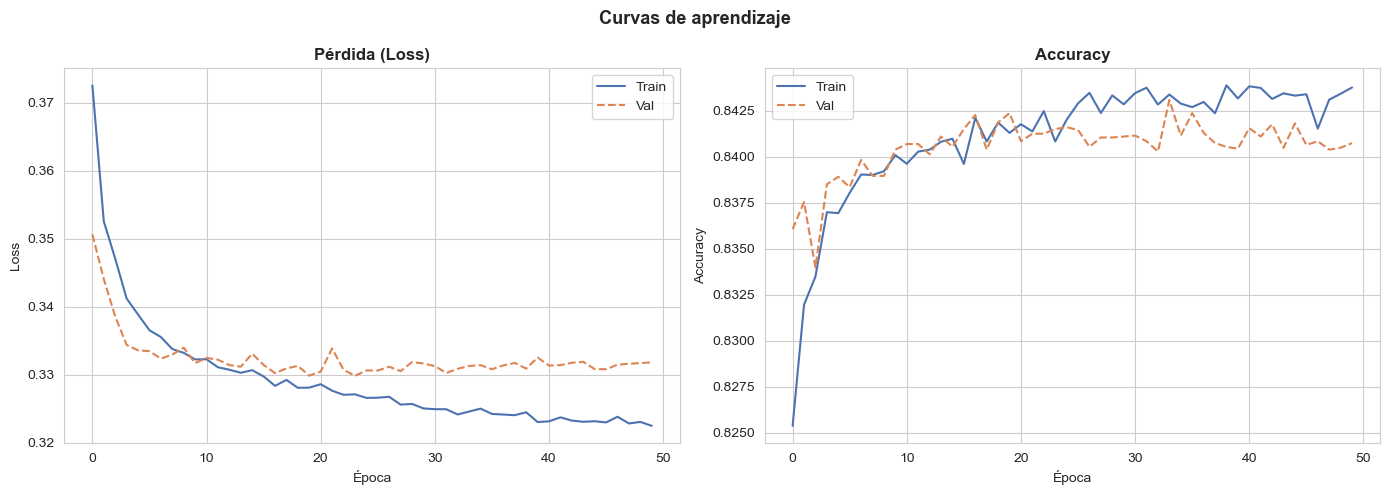

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history.history['loss'],     label='Train', color='#4C72B0')
axes[0].plot(history.history['val_loss'], label='Val',   color='#DD8452', linestyle='--')
axes[0].set_title('Pérdida (Loss)', fontweight='bold')
axes[0].set_xlabel('Época')
axes[0].set_ylabel('Loss')
axes[0].legend()

axes[1].plot(history.history['accuracy'],     label='Train', color='#4C72B0')
axes[1].plot(history.history['val_accuracy'], label='Val',   color='#DD8452', linestyle='--')
axes[1].set_title('Accuracy', fontweight='bold')
axes[1].set_xlabel('Época')
axes[1].set_ylabel('Accuracy')
axes[1].legend()

plt.suptitle('Curvas de aprendizaje', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [22]:
resultados = model.evaluate(test_ds, verbose=0)
metricas   = ['loss', 'accuracy', 'auc', 'recall', 'precision']

print("=== RESULTADOS EN TEST ===")
for m, v in zip(metricas, resultados):
    print(f"  {m:12s}: {v:.4f}")

=== RESULTADOS EN TEST ===
  loss        : 0.3365
  accuracy    : 0.8414
  auc         : 0.8518
  recall      : 0.9490
  precision   : 0.8699


In [23]:
# Una sola capa oculta pequeña
all_feats_concat = keras.layers.concatenate(feats_encoded)

x = keras.layers.Dense(16, activation='relu')(all_feats_concat)
output = keras.layers.Dense(1, activation='sigmoid')(x)

model_1 = keras.Model(inputs=inputs, outputs=output)
model_1.compile(optimizer='adam', loss='binary_crossentropy',
                metrics=['accuracy', keras.metrics.AUC(name='auc'),
                         keras.metrics.Recall(name='recall'),
                         keras.metrics.Precision(name='precision')])

print("Modelo 1 - Simple")
history_1 = model_1.fit(train_ds, epochs=50, validation_data=val_ds, verbose=0)
r1 = model_1.evaluate(test_ds, verbose=0)
print(f"  accuracy: {r1[1]:.4f} | auc: {r1[2]:.4f} | recall: {r1[3]:.4f} | precision: {r1[4]:.4f}")

Modelo 1 - Simple
  accuracy: 0.8400 | auc: 0.8519 | recall: 0.9571 | precision: 0.8632


Configurar ML flow

In [29]:
import mlflow
import mlflow.keras

mlflow.set_experiment("Saber11_Bolivar_UrbanoRural")
print("MLflow version:", mlflow.__version__)
print("Experimento configurado")

MLflow version: 3.12.0
Experimento configurado


### Función para entrenar MLflow

In [31]:
def run_experiment(nombre, cat_str, num, epochs=50):
    
    with mlflow.start_run(run_name=nombre):
        
        # ── Registrar parámetros ──────────────────────────────
        mlflow.log_param("cat_str_feats", cat_str)
        mlflow.log_param("num_feats", num)
        mlflow.log_param("epochs", epochs)
        mlflow.log_param("batch_size", 32)
        mlflow.log_param("arquitectura", "64-32-16")
        
        # ── Preparar datos ────────────────────────────────────
        all_f    = cat_str + num
        df_exp   = df[all_f + [TARGET]].dropna().copy()
        df_exp[TARGET] = (df_exp[TARGET] == 'URBANO').astype(int)
        
        train_e  = df_exp.sample(frac=0.8, random_state=42)
        test_e   = df_exp.drop(train_e.index)
        val_e    = train_e.sample(frac=0.2, random_state=42)
        train_e  = train_e.drop(val_e.index)
        
        train_ds_e = dataframe_to_dataset(train_e).batch(32)
        val_ds_e   = dataframe_to_dataset(val_e).batch(32)
        test_ds_e  = dataframe_to_dataset(test_e).batch(32)
        
        # ── Crear inputs y codificaciones ─────────────────────
        inputs_e = []
        for feat in cat_str:
            inputs_e.append(keras.Input(shape=(1,), name=feat, dtype="string"))
        for feat in num:
            inputs_e.append(keras.Input(shape=(1,), name=feat, dtype="float32"))
        
        feats_e = []
        for i, feat in enumerate(cat_str):
            feats_e.append(encode_categorical_feature(inputs_e[i], feat, train_ds_e, True))
        offset = len(cat_str)
        for i, feat in enumerate(num):
            feats_e.append(encode_numerical_feature(inputs_e[offset+i], feat, train_ds_e))
        
        # ── Arquitectura ──────────────────────────────────────
        x = keras.layers.concatenate(feats_e)
        x = keras.layers.Dense(64, activation='relu')(x)
        x = keras.layers.Dropout(0.3)(x)
        x = keras.layers.Dense(32, activation='relu')(x)
        x = keras.layers.Dropout(0.2)(x)
        x = keras.layers.Dense(16, activation='relu')(x)
        out = keras.layers.Dense(1, activation='sigmoid')(x)
        
        m = keras.Model(inputs_e, out)
        m.compile(optimizer='adam', loss='binary_crossentropy',
                  metrics=['accuracy',
                           keras.metrics.AUC(name='auc'),
                           keras.metrics.Recall(name='recall'),
                           keras.metrics.Precision(name='precision')])
        
        # ── Entrenar ──────────────────────────────────────────
        m.fit(train_ds_e, epochs=epochs, validation_data=val_ds_e, verbose=0)
        
        # ── Evaluar ───────────────────────────────────────────
        r = m.evaluate(test_ds_e, verbose=0)
        
        mlflow.log_metric("test_loss",      r[0])
        mlflow.log_metric("test_accuracy",  r[1])
        mlflow.log_metric("test_auc",       r[2])
        mlflow.log_metric("test_recall",    r[3])
        mlflow.log_metric("test_precision", r[4])
        
        print(f"\n{'='*50}")
        print(f"  {nombre}")
        print(f"  accuracy:  {r[1]:.4f}")
        print(f"  auc:       {r[2]:.4f}")
        print(f"  recall:    {r[3]:.4f}")
        print(f"  precision: {r[4]:.4f}")
        print(f"{'='*50}")
        
        return r

print("Función definida")

Función definida


#### Se corren los 3 modelos que se quieren evaluar que son solo las binarias, solo las numericas y el conjunto d elas 3

In [32]:
# Experimento 1 - Solo socioeconómicas
cat_socio = ['fami_estratovivienda', 'fami_educacionpadre',
             'fami_educacionmadre', 'fami_tieneinternet',
             'fami_tienecomputador', 'fami_tieneautomovil',
             'fami_tienelavadora', 'cole_naturaleza',
             'cole_jornada', 'cole_bilingue', 'cole_caracter']

r1 = run_experiment("E1_Solo_Socioeconomicas", cat_socio, [])

# Experimento 2 - Solo puntajes
r2 = run_experiment("E2_Solo_Puntajes", [],
                    ['punt_matematicas', 'punt_lectura_critica',
                     'punt_c_naturales', 'punt_sociales_ciudadanas',
                     'punt_ingles', 'punt_global'])

# Experimento 3 - Todas las variables
cat_todas = ['estu_genero', 'fami_estratovivienda', 'fami_educacionpadre',
             'fami_educacionmadre', 'fami_tieneinternet', 'fami_tienecomputador',
             'fami_tieneautomovil', 'fami_tienelavadora', 'cole_naturaleza',
             'cole_jornada', 'cole_bilingue', 'cole_caracter', 'cole_calendario']
num_todas = ['punt_matematicas', 'punt_lectura_critica', 'punt_c_naturales',
             'punt_sociales_ciudadanas', 'punt_ingles', 'punt_global', 'edad']

r3 = run_experiment("E3_Todas_Variables", cat_todas, num_todas)


  E1_Solo_Socioeconomicas
  accuracy:  0.8397
  auc:       0.8443
  recall:    0.9562
  precision: 0.8635

  E2_Solo_Puntajes
  accuracy:  0.8224
  auc:       0.6631
  recall:    1.0000
  precision: 0.8224

  E3_Todas_Variables
  accuracy:  0.8412
  auc:       0.8506
  recall:    0.9642
  precision: 0.8598
